In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from environment import Easy21, NNRecursiveWrapper
from empirical_qvi import EmpiricalQVI

In [20]:
env = Easy21()
solver = EmpiricalQVI(env, gamma=0.95, n_samples=250)

In [21]:
print("Running EQVI...")
q_table, deltas = solver.run(iterations=60)

Running EQVI...


EQVI Iterations: 100%|██████████| 60/60 [00:25<00:00,  2.34it/s]


# True Value Function Surface

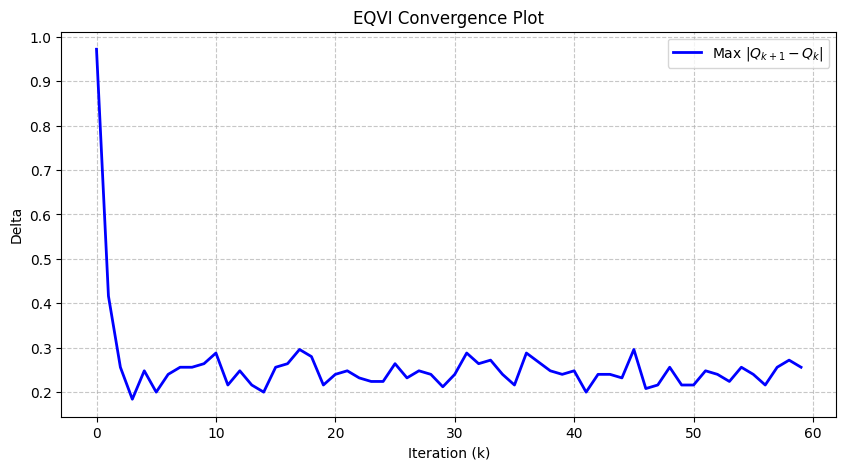

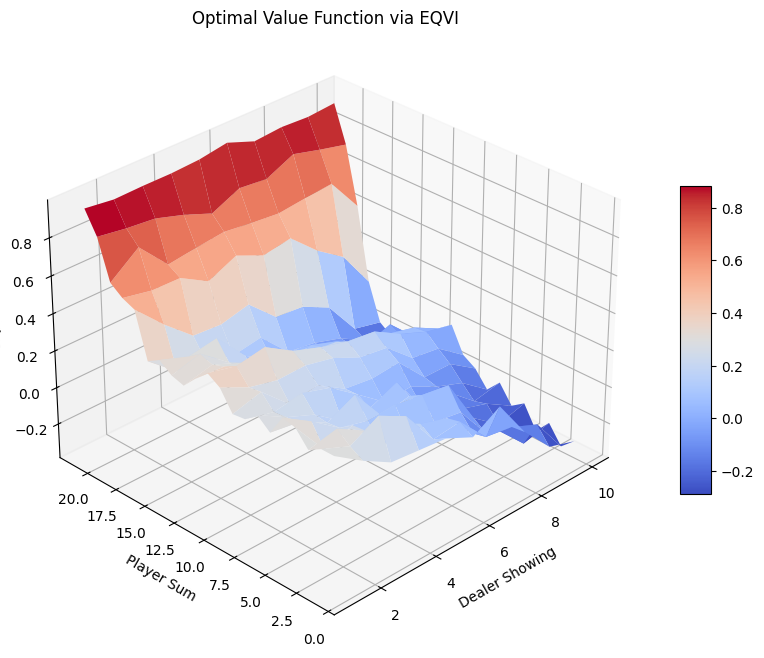

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(deltas, label='Max $|Q_{k+1} - Q_k|$', color='blue', linewidth=2)
plt.title("EQVI Convergence Plot")
plt.xlabel("Iteration (k)")
plt.ylabel("Delta")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

v_function = np.max(q_table, axis=2)

def plot_value_function(V, title):
    player_range = np.arange(1, 22)
    dealer_range = np.arange(1, 11)
    D, P = np.meshgrid(dealer_range, player_range)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(D, P, V, cmap='coolwarm', edgecolor='none')

    ax.set_xlabel('Dealer Showing')
    ax.set_ylabel('Player Sum')
    ax.set_zlabel('Value')
    ax.set_title(title)
    ax.view_init(elev=30, azim=-135)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
    plt.show()

plot_value_function(v_function, "Optimal Value Function via EQVI")

# True Policy

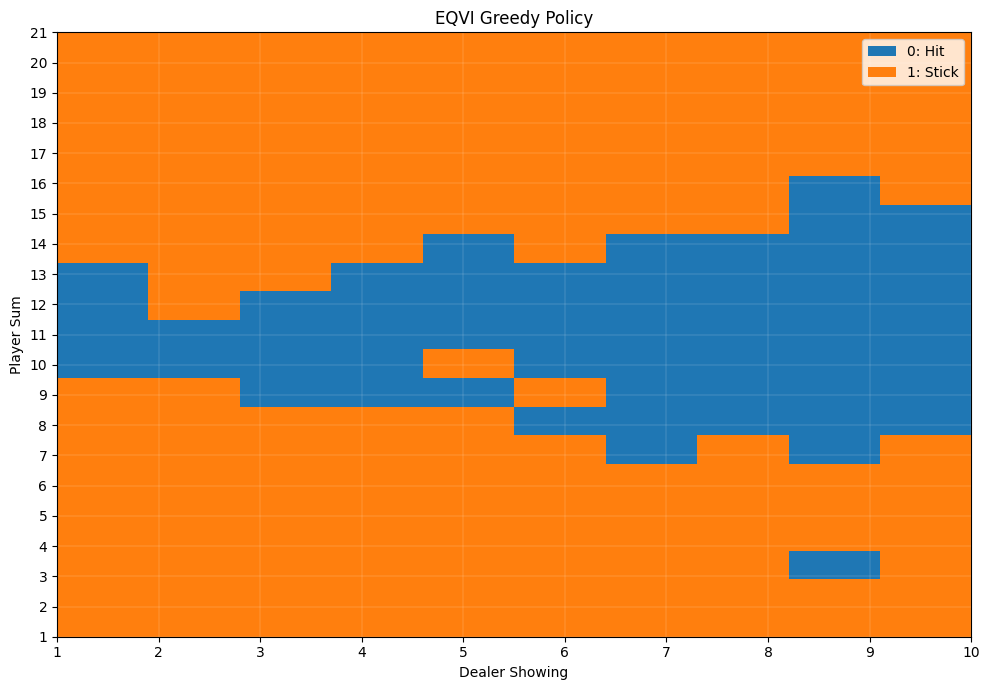

In [23]:
def plot_policy_heatmap(policy, title="EQVI Policy Heatmap"):
    if policy.shape != (21, 10):
        raise ValueError(f"Expected policy shape (21, 10), got {policy.shape}")

    cmap = ListedColormap(["#1f77b4", "#ff7f0e"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(
        policy,
        cmap=cmap,
        norm=norm,
        origin="lower",
        aspect="auto",
        extent=[1, 10, 1, 21],
    )

    ax.set_title(title)
    ax.set_xlabel("Dealer Showing")
    ax.set_ylabel("Player Sum")
    ax.set_xticks(np.arange(1, 11))
    ax.set_yticks(np.arange(1, 22))
    ax.grid(color="white", linestyle="-", linewidth=0.35, alpha=0.35)

    legend_handles = [
        Patch(facecolor="#1f77b4", label="0: Hit"),
        Patch(facecolor="#ff7f0e", label="1: Stick"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", frameon=True)

    plt.tight_layout()
    plt.show()

# Derive policy directly from the Q-table produced by EQVI
policy_eqvi = np.argmax(q_table, axis=2)
plot_policy_heatmap(policy_eqvi, "EQVI Greedy Policy")

In [24]:
def plot_surface_ax(ax, V):
    player_range = np.arange(1, 22)
    dealer_range = np.arange(1, 11)

    D, P = np.meshgrid(dealer_range, player_range)

    surf = ax.plot_surface(D, P, V, cmap='coolwarm',
                           edgecolor='none', antialiased=True)

    ax.set_xlabel('Dealer Showing')
    ax.set_ylabel('Player Sum')
    ax.set_zlabel('Value')

    ax.view_init(elev=30, azim=-135)

    return surf

In [25]:
def pretrain_NN(a, b):
    wrapper = NNRecursiveWrapper(Easy21(), a, b, buffer_size=42000)
    for _ in range(5000):
        wrapper.begin_next_buffer()
        p, d = wrapper.env.initGame()
        wrapper.step(p, d, np.random.randint(0, 2))
        wrapper.commit_next_buffer()

    loss_history = wrapper.train_model(epochs=500)
    return wrapper, loss_history

# Experiments under modified environment
- Different values of a (0, 0.3, 1), keeping b = 0.5
- Different value of b (0, 0.5, 1), keeping a = 0.5

In [26]:
def run_model_collapse_experiment(rec_env=None):
    # real_env = Easy21()
    # rec_env = NNRecursiveWrapper(real_env, a=a_val, b=b_val, buffer_size=42000)

    model = EmpiricalQVI(rec_env, n_samples=50)
    q_table, deltas = model.run(iterations=40)

    # return full q_table, derived value function, and deltas
    return q_table, np.max(q_table, axis=2), deltas

In [27]:
wrapper1, loss_real = pretrain_NN(a=1, b=0.5)
q_real, v_real, d_real = run_model_collapse_experiment(wrapper1)

wrapper2, loss_degen = pretrain_NN(a=0.3, b=0.5)
q_degen, v_degen, d_degen = run_model_collapse_experiment(wrapper2)

wrapper3, loss_collapse = pretrain_NN(a=0, b=0.5)
q_collapse, v_collapse, d_collapse = run_model_collapse_experiment(wrapper3)

EQVI Iterations: 100%|██████████| 40/40 [00:35<00:00,  1.13it/s]


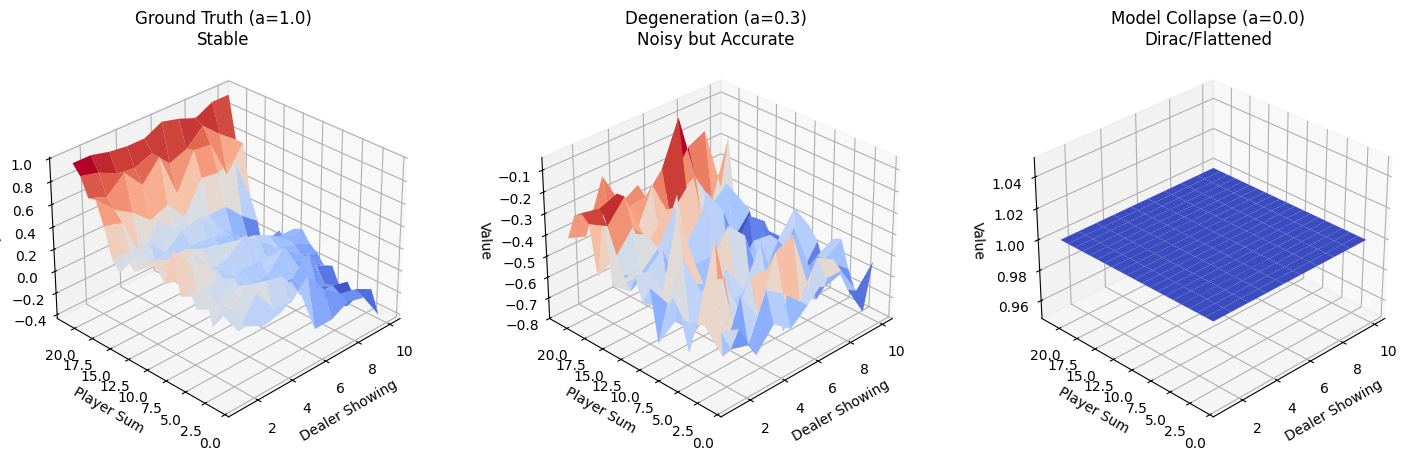

In [28]:
fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.set_title("Ground Truth (a=1.0)\nStable")
plot_surface_ax(ax1, v_real)

ax2 = fig.add_subplot(132, projection='3d')
ax2.set_title("Degeneration (a=0.3)\nNoisy but Accurate")
plot_surface_ax(ax2, v_degen)

ax3 = fig.add_subplot(133, projection='3d')
ax3.set_title("Model Collapse (a=0.0)\nDirac/Flattened")
plot_surface_ax(ax3, v_collapse)

plt.show()

In [29]:
wrapper4, loss_b0 = pretrain_NN(a=0.5, b=0)
q_degen_1, v_degen_1, d_degen_1 = run_model_collapse_experiment(wrapper4)

wrapper5, loss_b05 = pretrain_NN(a=0.5, b=0.5)
q_degen_half, v_degen_half, d_degen_half = run_model_collapse_experiment(wrapper5)

wrapper6, loss_b0_repeat = pretrain_NN(a=0.5, b=0)
q_degen_0, v_degen_0, d_degen_0 = run_model_collapse_experiment(wrapper6)

EQVI Iterations: 100%|██████████| 40/40 [00:10<00:00,  3.88it/s]


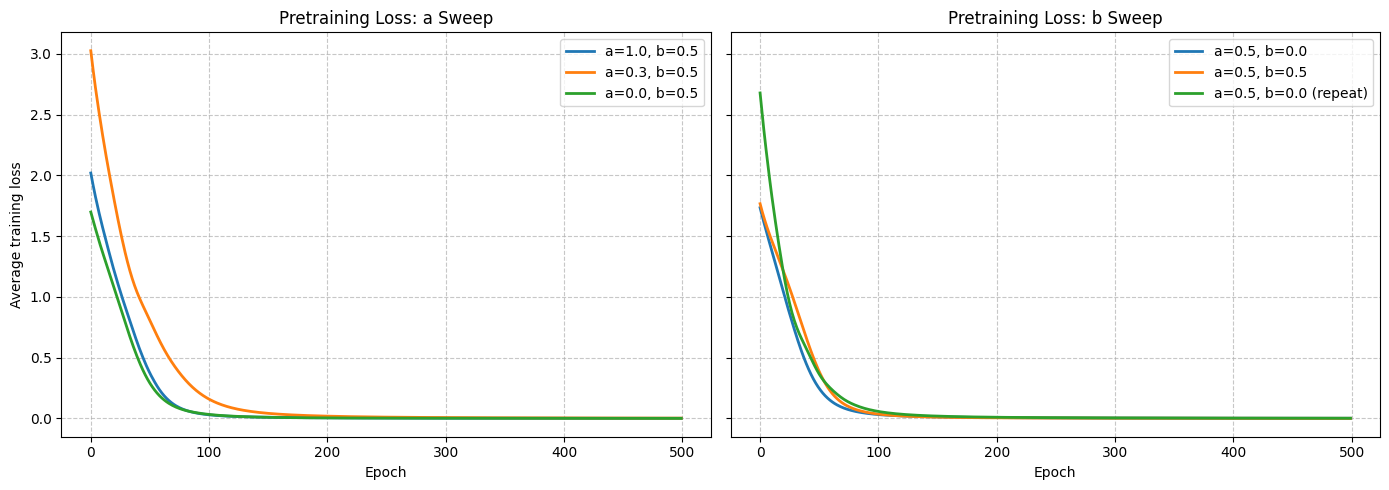

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(loss_real, label='a=1.0, b=0.5', linewidth=2)
axes[0].plot(loss_degen, label='a=0.3, b=0.5', linewidth=2)
axes[0].plot(loss_collapse, label='a=0.0, b=0.5', linewidth=2)
axes[0].set_title('Pretraining Loss: a Sweep')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Average training loss')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

axes[1].plot(loss_b0, label='a=0.5, b=0.0', linewidth=2)
axes[1].plot(loss_b05, label='a=0.5, b=0.5', linewidth=2)
axes[1].plot(loss_b0_repeat, label='a=0.5, b=0.0 (repeat)', linewidth=2)
axes[1].set_title('Pretraining Loss: b Sweep')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

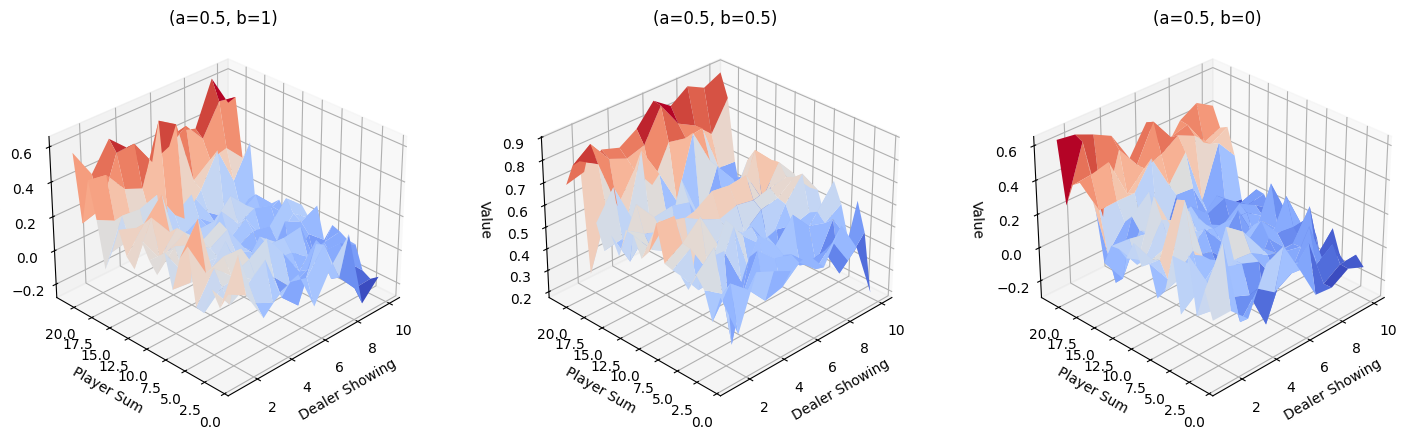

In [31]:
fig = plt.figure(figsize=(18, 5))

ax4 = fig.add_subplot(131, projection='3d')
ax4.set_title("(a=0.5, b=1)")
plot_surface_ax(ax4, v_degen_1)

ax5 = fig.add_subplot(132, projection='3d')
ax5.set_title("(a=0.5, b=0.5)")
plot_surface_ax(ax5, v_degen_half)

ax6 = fig.add_subplot(133, projection='3d')
ax6.set_title("(a=0.5, b=0)")
plot_surface_ax(ax6, v_degen_0)

plt.show()

# Learnt Policies for all the 6 cases

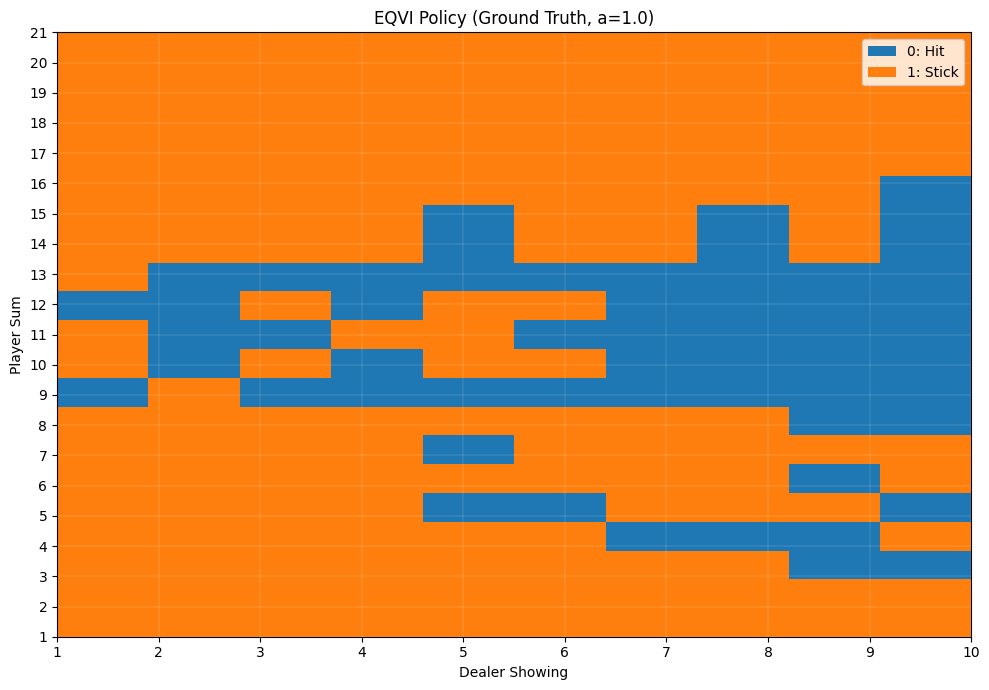

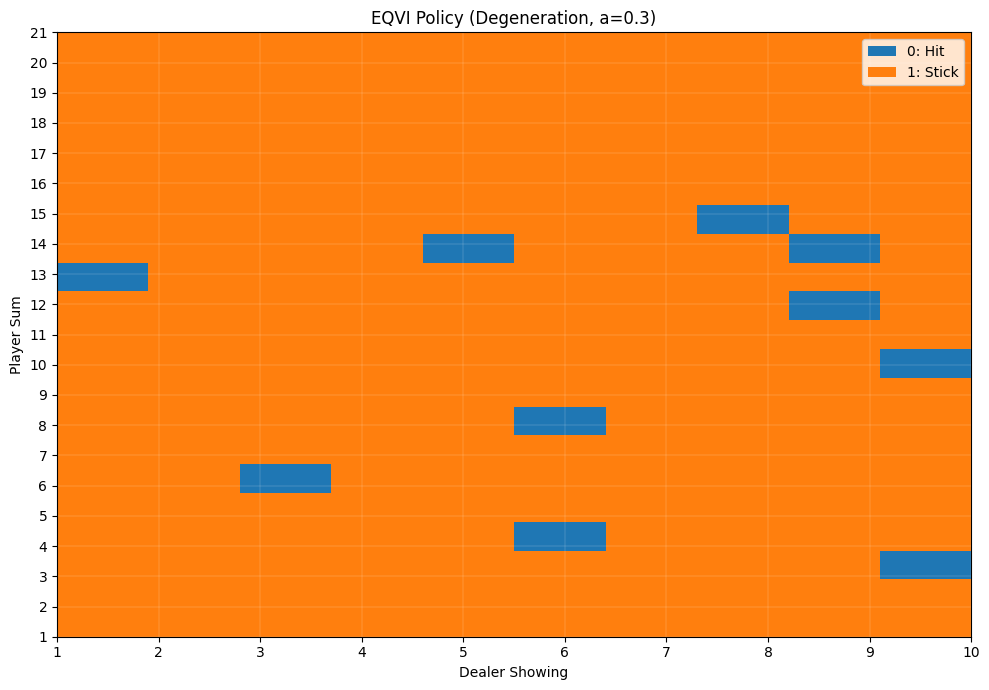

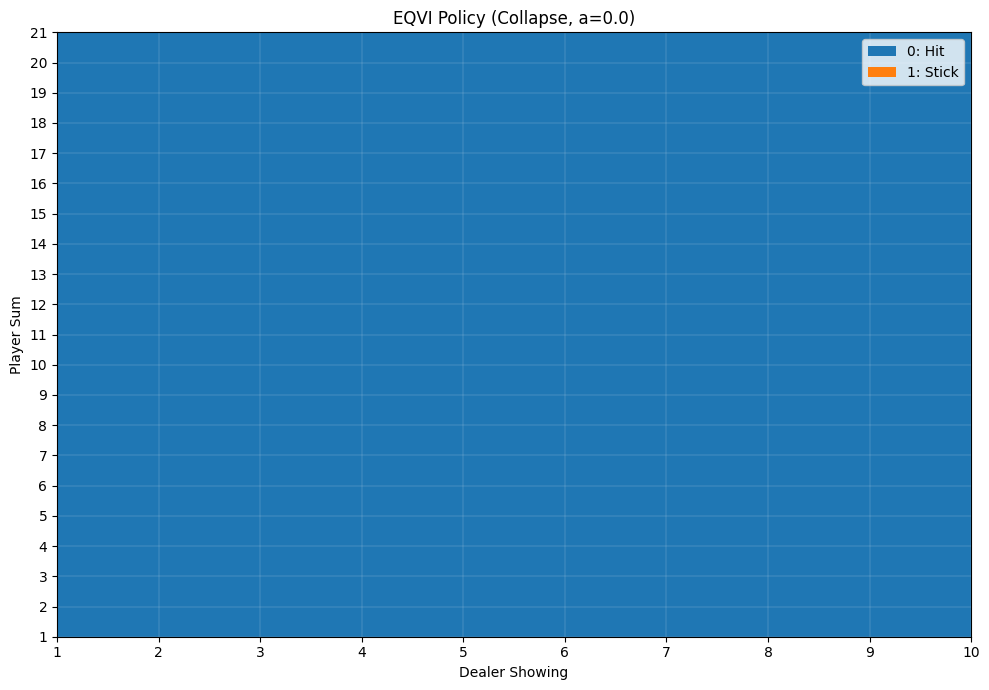

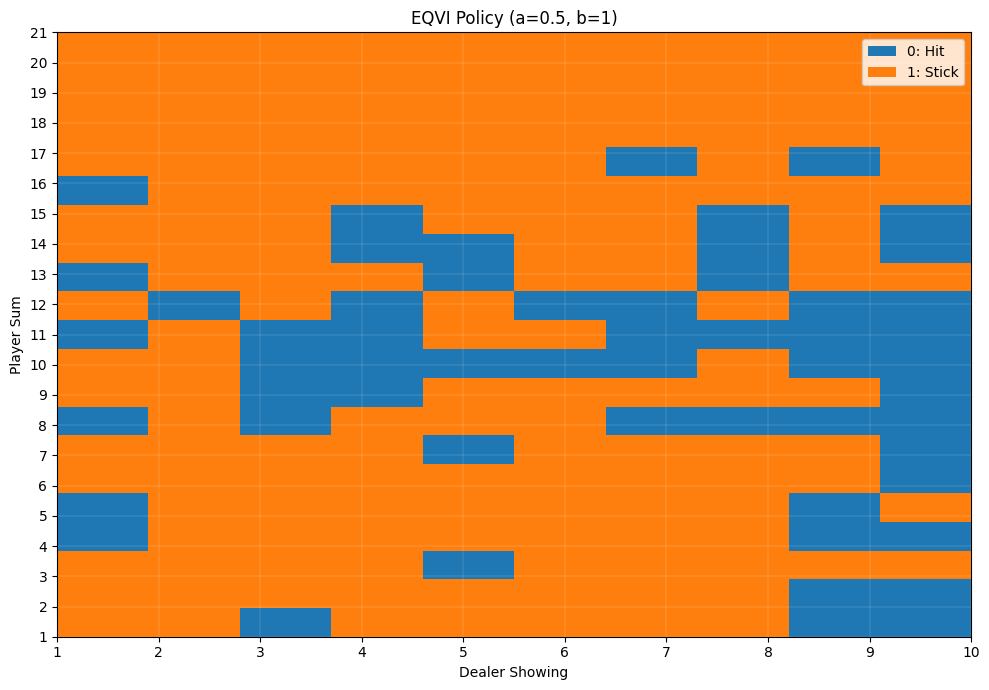

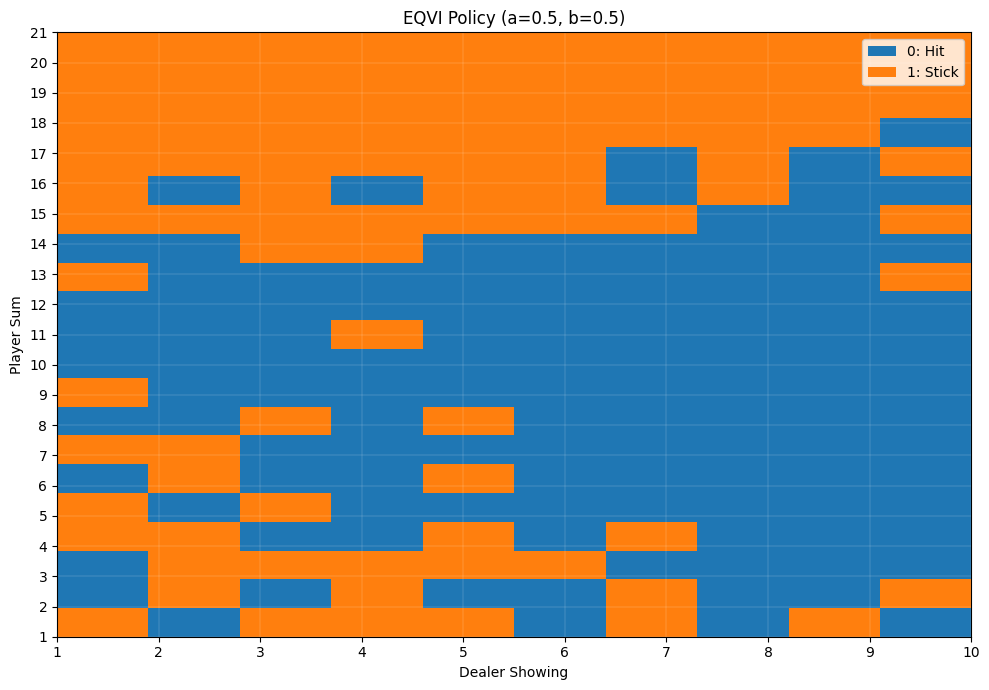

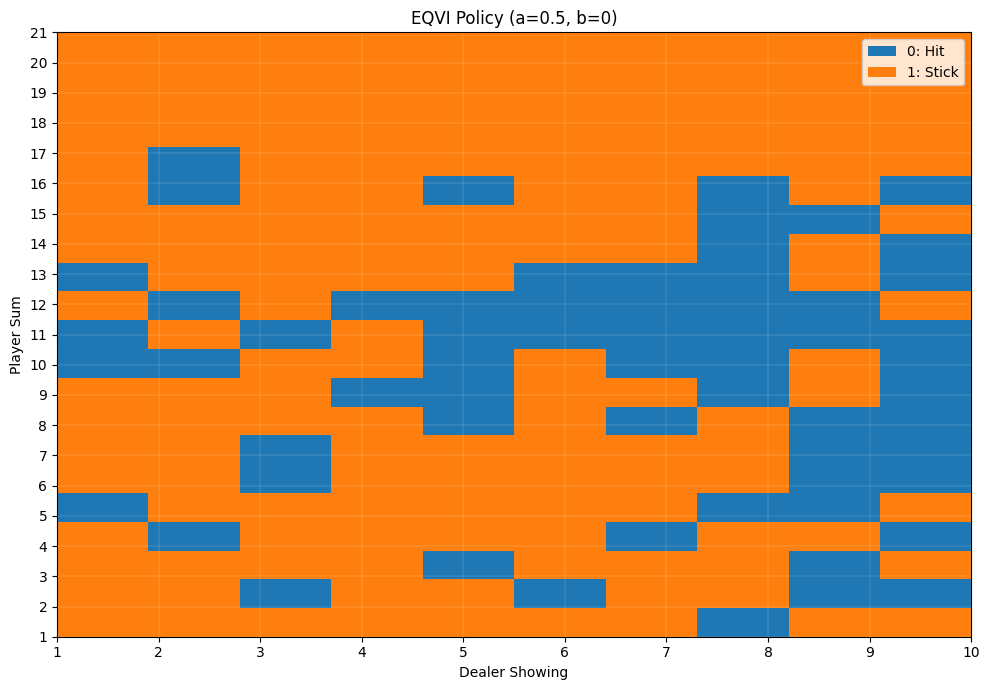

In [32]:
# Plot policies derived from q-tables for collapse experiments
policy_real = np.argmax(q_real, axis=2)
policy_degen = np.argmax(q_degen, axis=2)
policy_collapse = np.argmax(q_collapse, axis=2)
plot_policy_heatmap(policy_real, "EQVI Policy (Ground Truth, a=1.0)")
plot_policy_heatmap(policy_degen, "EQVI Policy (Degeneration, a=0.3)")
plot_policy_heatmap(policy_collapse, "EQVI Policy (Collapse, a=0.0)")

# Plot policies for b-sweep experiments
policy_degen_1 = np.argmax(q_degen_1, axis=2)
policy_degen_half = np.argmax(q_degen_half, axis=2)
policy_degen_0 = np.argmax(q_degen_0, axis=2)
plot_policy_heatmap(policy_degen_1, "EQVI Policy (a=0.5, b=1)")
plot_policy_heatmap(policy_degen_half, "EQVI Policy (a=0.5, b=0.5)")
plot_policy_heatmap(policy_degen_0, "EQVI Policy (a=0.5, b=0)")